In [1]:
import pandas as pd
import numpy as np

file = pd.read_csv("exam_2024.csv")
data = pd.get_dummies(file)
data = data.sample(frac=1).reset_index(drop=True)

# Display the DataFrame in table format
display(file)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


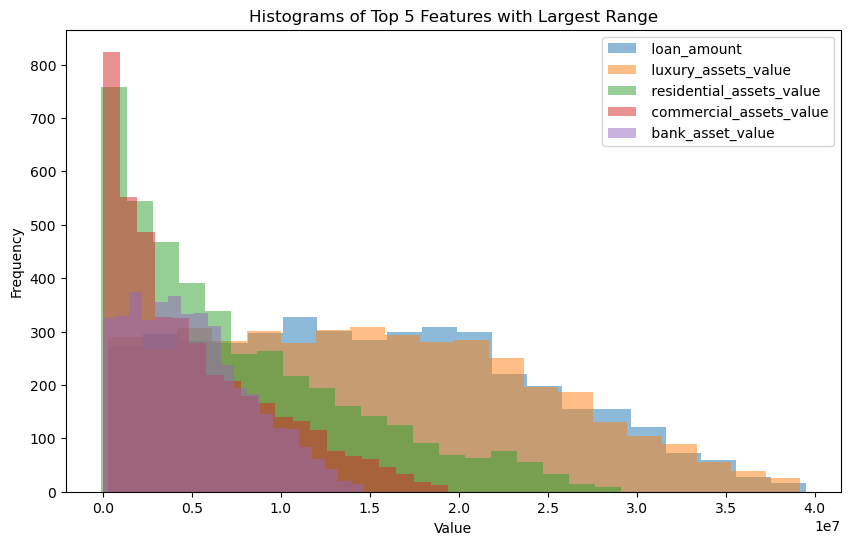

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'file' is your DataFrame read from the CSV
file = pd.read_csv("exam_2024.csv")

# Select only numeric columns
numeric_columns = file.select_dtypes(include=[np.number])

# Calculate the range of each feature
feature_ranges = numeric_columns.max() - numeric_columns.min()

# Sort the features by their range in descending order and select the top 5
top_5_features = feature_ranges.sort_values(ascending=False).head(5)

# Plot the selected features
plt.figure(figsize=(10, 6))
for feature in top_5_features.index:
    plt.hist(numeric_columns[feature], bins=20, alpha=0.5, label=feature)

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histograms of Top 5 Features with Largest Range')
plt.legend()
plt.show()


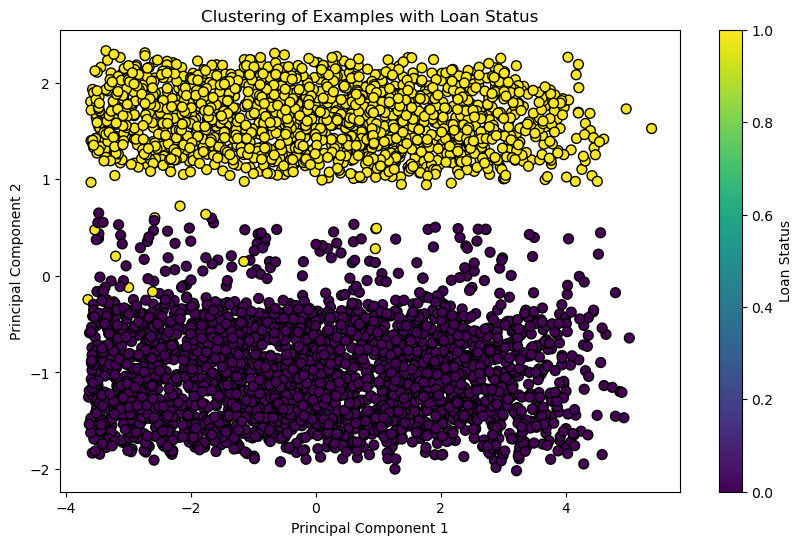

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Load the data
file = pd.read_csv("exam_2024.csv")

# Assuming 'loan_status' is the correct column name
loan_status_column = ' loan_status'

# Convert loan_status column to numeric labels
label_encoder = LabelEncoder()
file['loan_status_numeric'] = label_encoder.fit_transform(file[loan_status_column])

# Extract features (numeric columns) for clustering
features = file.select_dtypes(include=[np.number])

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply PCA for dimensionality reduction to 2 dimensions
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)  # Assuming 2 clusters
clusters = kmeans.fit_predict(principal_components)

# Plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=file['loan_status_numeric'], cmap='viridis', edgecolor='k', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clustering of Examples with Loan Status')
plt.colorbar(label='Loan Status')
plt.show()


Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.9765739385065885


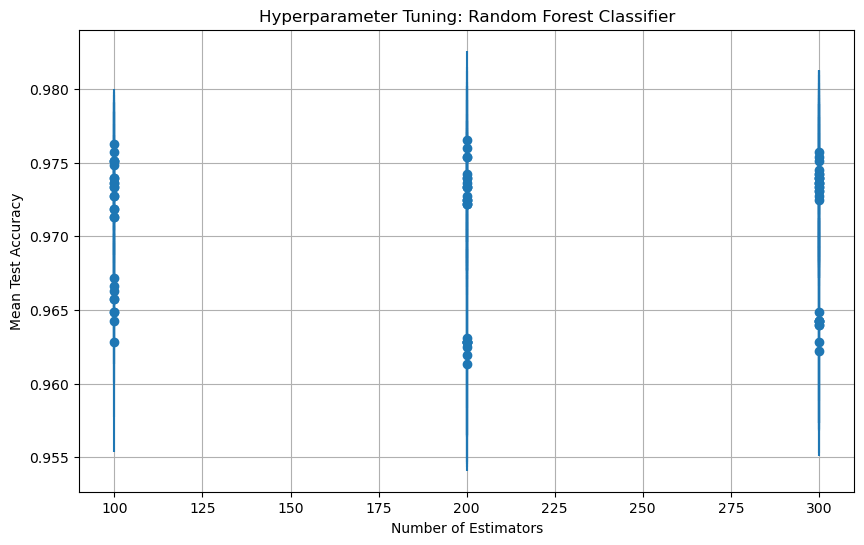

Test Accuracy: 0.9789227166276346


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the data
file = pd.read_csv("exam_2024.csv")

# Assuming 'loan_status' is the target variable
target_variable = ' loan_status'

# Define features and target
X = file.drop(columns=[target_variable])
y = file[target_variable]

# Encode categorical variables
X_encoded = pd.get_dummies(X)

# Handle missing values if any
# For example:
# X_encoded = X_encoded.fillna(X_encoded.mean())  # Replace missing values with mean

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Define the algorithm (Random Forest Classifier)
model = RandomForestClassifier(random_state=42)

# Define the hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Define evaluation metric (accuracy)
scoring = 'accuracy'

# Define cross-validation strategy (5-fold cross-validation)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform hyperparameter tuning using GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kf)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Hyperparameters:", best_params)
print("Best Accuracy:", best_score)

# Visualize the distribution of the evaluation metric
cv_results = pd.DataFrame(grid_search.cv_results_)

# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(cv_results['param_n_estimators'], cv_results['mean_test_score'], yerr=cv_results['std_test_score'], fmt='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Test Accuracy')
plt.title('Hyperparameter Tuning: Random Forest Classifier')
plt.grid(True)
plt.show()

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

In [5]:
def create_teaching_schedule(data, initial_training_size, batch_size):
    teaching_schedule = []

    # Initial training set
    initial_training_set = data[:initial_training_size]
    teaching_schedule.append(initial_training_set)

    # Iterate over the dataset in batches
    start_index = initial_training_size
    while start_index < len(data):
        # Take the next batch of examples
        end_index = start_index + batch_size
        if end_index > len(data):
            end_index = len(data)
        batch = data[start_index:end_index]

        # Combine with the previous training set
        combined_set = pd.concat([teaching_schedule[-1], batch], ignore_index=True)
        teaching_schedule.append(combined_set)

        # Update start index
        start_index = end_index

    return teaching_schedule

# Assuming 'data' is your shuffled DataFrame and '500' is the initial training size, '100' is the batch size
teaching_schedule = create_teaching_schedule(data, initial_training_size=500, batch_size=100)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the data
file = pd.read_csv("exam_2024.csv")

# Define the target variable name
target_variable = ' loan_status'

# Define the best hyperparameters obtained from question 4
best_params = {
    'n_estimators': 200,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}

# Define the Teaching Schedule function from question 5
def create_teaching_schedule(data, initial_training_size, batch_size):
    teaching_schedule = []

    # Initial training set
    initial_training_set = data[:initial_training_size]
    teaching_schedule.append(initial_training_set)

    # Iterate over the dataset in batches
    start_index = initial_training_size
    while start_index < len(data):
        # Take the next batch of examples
        end_index = start_index + batch_size
        if end_index > len(data):
            end_index = len(data)
        batch = data[start_index:end_index]

        # Combine with the previous training set
        combined_set = pd.concat([teaching_schedule[-1], batch], ignore_index=True)
        teaching_schedule.append(combined_set)

        # Update start index
        start_index = end_index

    return teaching_schedule

# Define the RandomForestClassifier with the best hyperparameters
best_model = RandomForestClassifier(**best_params, random_state=42)

# Load the data
file = pd.read_csv("exam_2024.csv")

# Define the Teaching Schedule parameters
initial_training_size = 500
batch_size = 100

# Create the Teaching Schedule
teaching_schedule = create_teaching_schedule(file, initial_training_size, batch_size)

# Initialize lists to store batch numbers and corresponding evaluation metric values
batch_numbers = []
accuracy_scores = []

# Iterate over the teaching schedule
for batch_number, batch_data in enumerate(teaching_schedule):
    # Check if 'loan_status' exists in batch_data columns
    if target_variable in batch_data.columns:
        # Split the batch data into features (X) and target (y)
        X_batch = batch_data.drop(columns=[target_variable])
        y_batch = batch_data[target_variable]

        # Encode categorical variables
        X_batch_encoded = pd.get_dummies(X_batch)

        # Train the model on the current batch
        best_model.fit(X_batch_encoded, y_batch)

        # Predict labels for the current batch
        y_pred_batch = best_model.predict(X_batch_encoded)

        # Calculate accuracy for the current batch
        accuracy_batch = accuracy_score(y_batch, y_pred_batch)

        # Append batch number and accuracy to lists
        batch_numbers.append(batch_number)
        accuracy_scores.append(accuracy_batch)
    else:
        print(f"Column '{target_variable}' not found in batch_data.")

# Visualize the evaluation metric (accuracy) as a function of batch number
plt.figure(figsize=(10, 6))
plt.plot(batch_numbers, accuracy_scores, marker='o')
plt.xlabel('Batch Number')
plt.ylabel('Accuracy')
plt.title('Accuracy as a Function of Batch Number')
plt.grid(True)
plt.show()
